Chapter 32
# 支持向量机，线性核
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

##支持向量机

图 7 所示为支持向量机 (Support Vector Machine, SVM) 核心思路。

如图 7 所示，一片湖面左右散布着蓝色 ● 红色 ● 礁石，游戏规则是，皮划艇以直线路径穿越水
道，保证船身恰好紧贴礁石。寻找一条路径，让该路径通过的皮划艇宽度最大。很明显，图 7 (b) 中
规划的路径好于图 7 (a)。

图 7 (b) 中加黑圈 ○ 的五个点，就是所谓的支持向量 (support vector)。


图 7 中深蓝色线，便是决策边界，也称分离超平面 (separating hyperplane)。特别提醒大
家注意一点，加黑圈 ○ 支持向量确定决策边界位置；其他数据并没有起到任何作用。因此，SVM 对于
数据特征数量远高于数据样本量的情况也有效。


图 7 中两条虚线之间宽度叫做间隔 (margin)。支持向量机的优化目标为——间隔最大化。


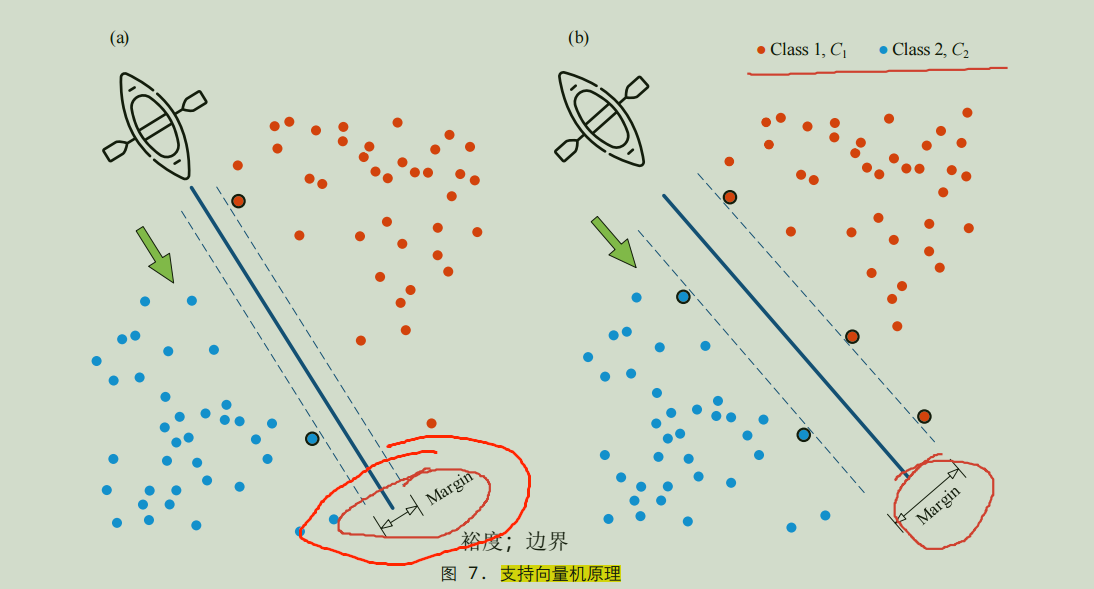

从数据角度，图 7 两类数据用一条直线便可以分割开来，这种数据叫做线性可分 (linearly
separable)。线性可分问题采用硬间隔 (hard margin)；白话说，硬间隔指的是，间隔内没有数
据点。


实践中，并不是所有数据都是线性可分。多数时候，数据线性不可分 (non-linearly
separable)。


如图 8 所示，不能找到一条直线将蓝色 ● 红色 ● 数据分离。
对于线性不可分问题，就要引入两种方法——软间隔 (soft margin) 和核技巧 (kernel
trick)。

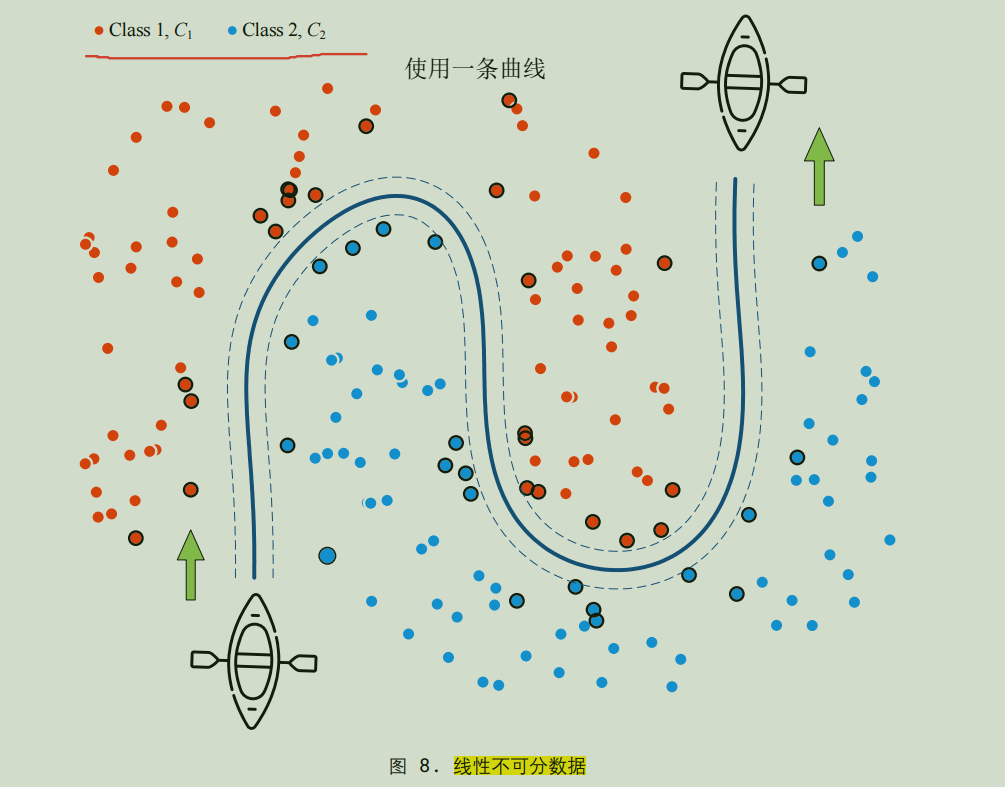

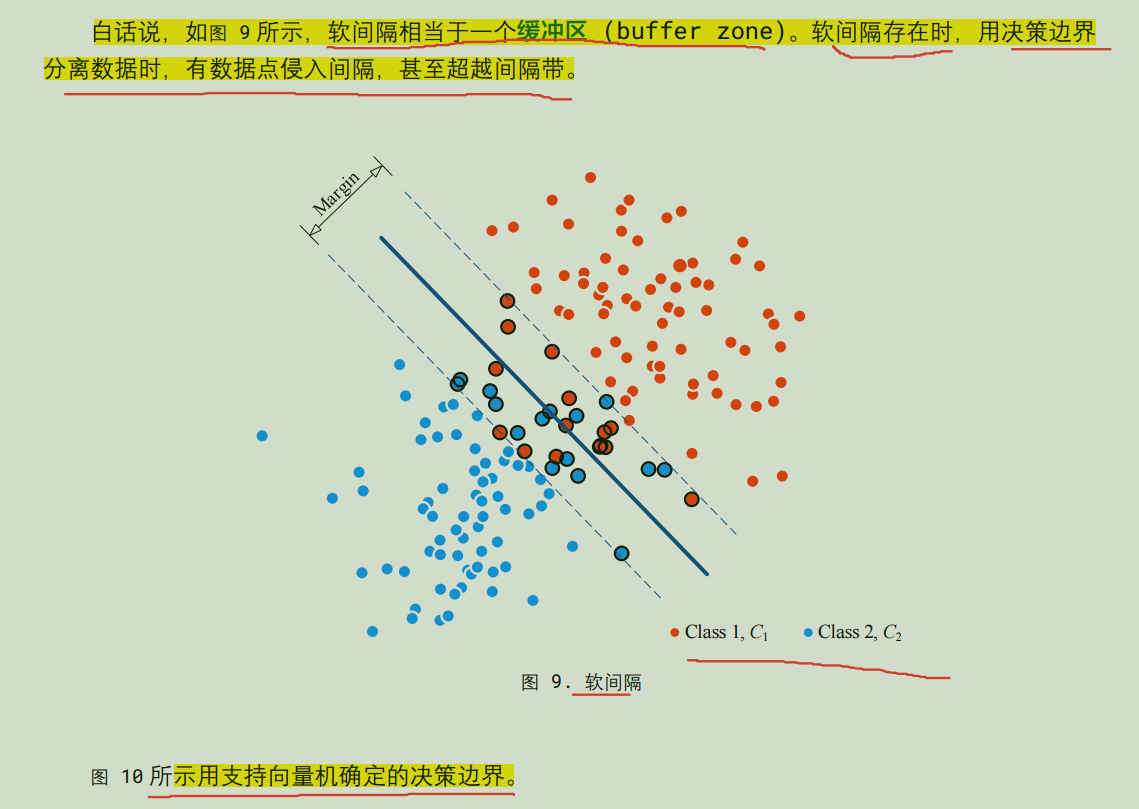

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap # 颜色映射
from sklearn import neighbors, datasets

# 导入并整理数据

In [3]:
# 导入并整理数据
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

## 生成网格化数据

In [4]:
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)

### 创建色谱

In [5]:
# 创建色谱
rgb = [[255, 238, 255],
       [219, 238, 244],
       [228, 228, 228]]
rgb = np.array(rgb)/255. # 归一化

# 预测区域
cmap_light = ListedColormap(rgb)
cmap_bold = [[255, 51, 0],
             [0, 153, 255],
             [138,138,138]]

  # 数据点
cmap_bold = np.array(cmap_bold)/255. # 归一化

#线性核 (linear kernel) 是 SVM 中最简单的核函数之一。它适用于处理线性可分的数据集，
即可以通过一个直线 (在二维空间中) 或一个超平面 (在高维空间中) 将不同类别的样本点分开。


即可以通过**一个直线 (在二维空间中**) 或**一个超平面 (在高维空间中)** 将不同类别的样本点分开。

In [6]:
q = np.c_[xx1.ravel(), xx2.ravel()]
from sklearn import svm
# 创建支持向量机 (线性核) 分类器对象
SVM = svm.SVC(kernel='linear')
# 用训练数据训练kNN
SVM.fit(X, y) # 训练数据;原始数据与标签
# 用支持向量机 (线性核) 分类器对一系列查询点进行预测
y_predict = SVM.predict(q)
y_predict = y_predict.reshape(xx1.shape)

# 可视化

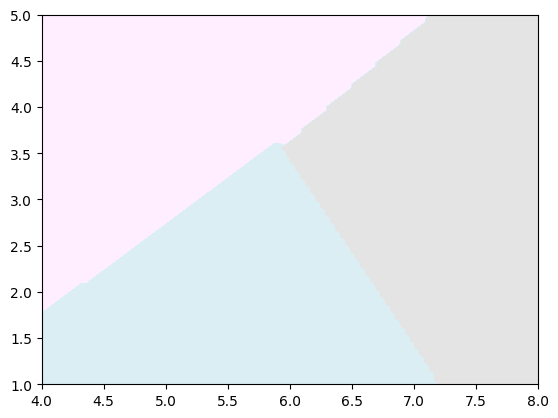

In [7]:
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)

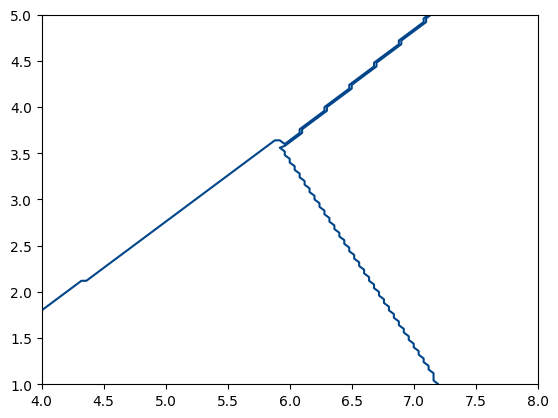

In [8]:
# 可视化
fig, ax = plt.subplots()
#plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

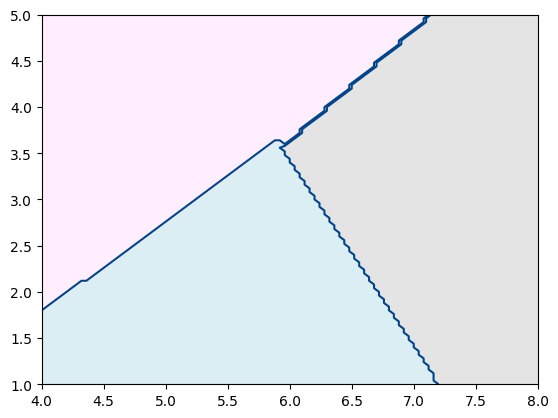

In [9]:
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

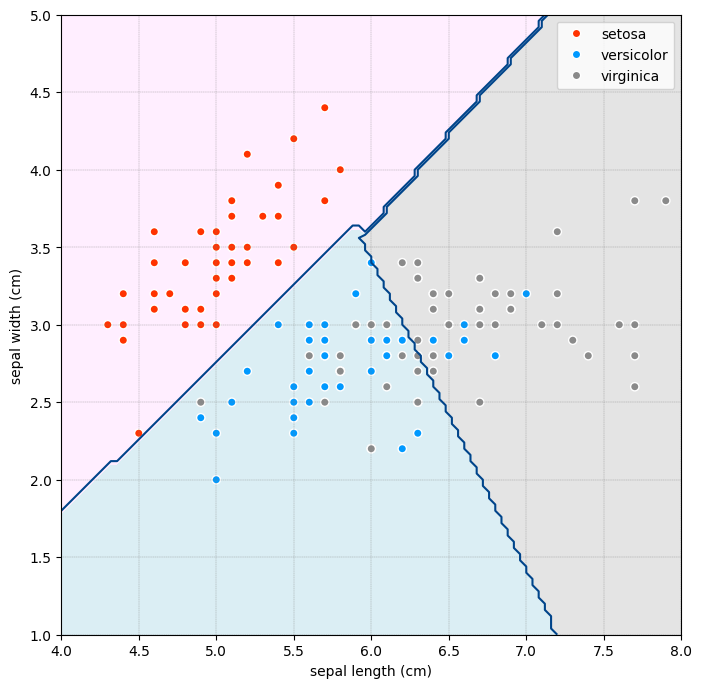

In [13]:
# 可视化
fig, ax = plt.subplots(figsize=(8,10))
# 绘制等高线
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

# 绘制散点图
sns.scatterplot(x=X[:, 0], y=X[:, 1],
                hue=iris.target_names[y], # 按照 'species' 列的值对数据点进行颜色分类
                ax = ax, # 轴对象
                palette=dict(setosa=cmap_bold[0,:], #设置颜色配色方案
                versicolor=cmap_bold[1,:],
                virginica=cmap_bold[2,:]),
                alpha=1.0,
                linewidth = 1, edgecolor=[1,1,1]) # 边缘为白色
plt.xlim(4, 8); plt.ylim(1, 5)  # 范围
plt.xlabel(iris.feature_names[0])  # 标签
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box')  #x,y轴比例一致